In [1]:
# !pip install uv

In [2]:
try:
    import lightgbm as lgb
except:
    !uv pip install -q lightgbm
    import lightgbm as lgb

lgb.__version__

'4.6.0'

In [3]:
## -- System dependencies --
import os, sys, gc
import torch

## -- Device-Agnostic (GPU/CPU) --
def get_system_info():
    if torch.cuda.is_available():
        return f"GPU: {torch.cuda.get_device_name(0)}"
    else:
        return f"CPU: {os.cpu_count()}"

get_system_info()

'CPU: 4'

In [4]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
import itertools
from time import time, sleep
from tqdm import tqdm

## -- Machine Learning --
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split, cross_val_score

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [5]:
## -- Set Configuration --
# sklearn.set_config(transform_output="pandas")
# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

# plt.rcParams['axes.prop_cycle'] = cycler(color=['red', 'green', 'blue'])
plt.rcParams.update({
    # "figure.facecolor": '#0f0f1a', # Outer panel (figure)
    # "axes.facecolor":   '#1a1a2e', # Inner panel (image)
    # "axes.edgecolor":   '#444466',
    # "axes.labelcolor":  '#e0e0ff',
    # "text.color":       'lightblue',
    # "xtick.color":      '#e0e0ff',
    # "ytick.color":      '#e0e0ff',
    # "grid.color":       '#2a2a4a',
    # "grid.alpha":       0.5,
    "font.family":      'monospace',
})

PALETTE = ['c', 'r', 'darkorange', '#3A86FF', 'y']
sns.set_palette(PALETTE)
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS': 5,
    'SEED': 42,
    'GREEN': '\033[32m',
    'YELLOW': '\033[33m',
    'RESET': '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [6]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --

PLATFORM = "kaggle" # -> 'colab' 'kaggle'

if PLATFORM == "kaggle":
    PATH = "/kaggle/input/competitions/playground-series-s6e9/"
    submission = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')

    ORIG_PATH = "/kaggle/input/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety/"
    orig = pd.read_csv(ORIG_PATH+"EV_Adoption_and_Range_Anxiety_Dataset.csv")
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = "/content/drive/MyDrive/-- shared_notebooks --/Ps6e9 | EV Purchase/_ev_purchase_data/"
    submission = pd.read_csv(PATH+"sample_submission.csv")
    train = pd.read_csv(PATH+"train.csv")
    test = pd.read_csv(PATH+"test.csv")
    orig = pd.read_csv(PATH+"EV_Adoption_and_Range_Anxiety_Dataset.csv")

## =================================================================================

ID     = "id"
TARGET = 'Will_Buy_EV'

obj = train.select_dtypes(include=["object", "category"]).columns.tolist()

cat_cols  = [c for c in obj if c not in [TARGET, ID]]
num_cols  = [c for c in train.columns if c not in cat_cols+[TARGET, ID]]
base_cols = cat_cols + num_cols

train[TARGET] = train[TARGET].map({'No': 0, 'Yes': 1})
orig[TARGET]  = orig[TARGET].map({'No': 0, 'Yes': 1})

FEATURES = [c for c in train.columns if c not in [ID, TARGET]]

orig = orig[FEATURES+[TARGET]]
print("Total Features:", len(FEATURES))

for (name, df) in {"Train": train, "Test": test , "Orig": orig}.items(): #
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Nums: {len(num_cols)}")
print(f"Total Cats: {len(cat_cols)}")
print(f"Total base: {len(base_cols)}")

Total Features: 13
Train shape: (668665, 15)
Test shape: (286571, 14)
Orig shape: (10000, 14)

Total Nums: 7
Total Cats: 6
Total base: 13


In [7]:
for c in num_cols:
    orig[c] = orig[c].fillna(orig[c].median())

print(orig.isna().sum())

Age                            0
Annual_Income_USD              0
Daily_Commute_km               0
Number_of_Cars_Owned           0
Charging_Stations_Near_Home    0
Charging_Stations_Near_Work    0
Environmental_Concern_Level    0
Gender                         0
City_Type                      0
Current_Car_Type               0
Home_Charging_Possible         0
Subsidy_Available              0
Range_Anxiety_Level            0
Will_Buy_EV                    0
dtype: int64


In [8]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
combined = pd.concat([train, test, orig])

digits_cols = []
cols_select = ["Annual_Income_USD", "Daily_Commute_km", "Age"]

for col in cols_select:
    scaled = np.rint(combined[col] * 10**4).astype("int64")
    for k in range(-4, 4):
        dig_col = f"{col}_digit{k}"
        combined[dig_col] = (scaled // 10**(k + 4) % 10).astype('int8').astype('category')
        digits_cols.append(dig_col)

train = combined.iloc[:len(train)][list(set(base_cols + FEATURES + digits_cols)) + [TARGET]]
test = combined.iloc[len(train):len(train)+len(test)][list(set(base_cols + FEATURES + digits_cols))]
orig = combined.iloc[-len(orig):][list(set(base_cols + FEATURES + digits_cols)) + [TARGET]]

# Check nunique, and find which ones are < 2
unique_counts = train[digits_cols].nunique()
drop_cols = unique_counts[unique_counts < 2].index.tolist()

# update digit cols for keep
digits_cols = [i for i in set(digits_cols) if i not in set(drop_cols)]

# drop constant features
train = train.drop(columns=drop_cols)
test  = test.drop(columns=drop_cols)
orig  = orig.drop(columns=drop_cols)

# num_cols = list(set(num_cols + digits_cols))
# cat_cols = list(set(cat_cols + digits_cols))

print(f"Total digit features: {len(digits_cols)}\n")
del combined

train

Total digit features: 9



,Annual_Income_USD_digit3,Daily_Commute_km_digit1,Annual_Income_USD_digit2,Daily_Commute_km_digit0,Number_of_Cars_Owned,Age_digit0,Range_Anxiety_Level,Daily_Commute_km_digit-1,Daily_Commute_km,Charging_Stations_Near_Home,Age,Annual_Income_USD_digit1,Charging_Stations_Near_Work,City_Type,Environmental_Concern_Level,Gender,Current_Car_Type,Age_digit1,Subsidy_Available,Home_Charging_Possible,Annual_Income_USD,Annual_Income_USD_digit0,Will_Buy_EV
0,2,2,8,3,2,6,Low,4,23.4,3,66,8,7,Suburban,1.0,Male,Sedan,6,No,Yes,92887.0,7,0.0
1,0,0,0,5,1,8,Low,0,5.0,2,38,0,2,Rural,4.0,Male,SUV,3,No,Yes,30000.0,0,0.0
2,4,3,3,6,1,6,Low,8,36.8,8,26,8,15,Urban,5.0,Female,Sedan,2,Yes,No,94389.0,9,1.0
3,3,2,5,3,2,6,Low,7,23.7,6,66,8,9,Suburban,3.0,Male,Hatchback,6,No,Yes,73580.0,0,0.0
4,7,5,8,0,1,4,Low,8,50.8,2,54,9,3,Suburban,3.0,Male,Hatchback,5,No,Yes,57898.0,8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,1,2,0,7,2,0,Medium,4,27.4,5,30,9,6,Urban,5.0,Male,Sedan,3,Yes,No,71090.0,0,0.0
668661,9,0,9,5,2,2,Low,0,5.0,5,32,9,4,Suburban,1.0,Female,SUV,3,Yes,Yes,129990.0,0,0.0
668662,1,2,7,4,1,4,Low,2,24.2,5,64,9,6,Suburban,1.0,Female,Hatchback,6,Yes,Yes,121791.0,1,0.0
668663,5,4,9,3,2,1,Low,7,43.7,0,51,2,0,Rural,1.0,Female,SUV,5,Yes,Yes,115923.0,3,0.0


In [9]:
INTER = []

combo_2_list = list(itertools.combinations(digits_cols, 2)) #+ cat_cols
for c1, c2 in tqdm(combo_2_list, desc='Pairwise'):
    n_col = f"Bi_{c1}_{c2}"
    train[n_col] = (train[c1].astype(str) + '_' + train[c2].astype(str)).factorize()[0]
    test[n_col]  = (test[c1].astype(str) + '_' + test[c2].astype(str)).factorize()[0]
    orig[n_col]  = (orig[c1].astype(str) + '_' + orig[c2].astype(str)).factorize()[0]
    INTER.append(n_col)

combo_3_list = list(itertools.combinations(digits_cols, 3))
for c1, c2, c3 in tqdm(combo_3_list, desc='Triplewise'):
    n_col = f"Tri_{c1}_{c2}_{c3}"
    train[n_col] = (train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)).factorize()[0]
    test[n_col]  = (test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)).factorize()[0]
    orig[n_col]  = (orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + orig[c3].astype(str)).factorize()[0]
    INTER.append(n_col)

combo_2_list2 = list(itertools.combinations(cat_cols, 2))
for c1, c2 in tqdm(combo_2_list2, desc='Pairwise'):
    n_col = f"Bi_{c1}_{c2}"
    train[n_col] = (train[c1].astype(str) + '_' + train[c2].astype(str)).factorize()[0]
    test[n_col]  = (test[c1].astype(str) + '_' + test[c2].astype(str)).factorize()[0]
    orig[n_col]  = (orig[c1].astype(str) + '_' + orig[c2].astype(str)).factorize()[0]
    INTER.append(n_col)

combo_3_list2 = list(itertools.combinations(cat_cols, 3))
for c1, c2, c3 in tqdm(combo_3_list2, desc='Triplewise'):
    n_col = f"Tri_{c1}_{c2}_{c3}"
    train[n_col] = (train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)).factorize()[0]
    test[n_col]  = (test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)).factorize()[0]
    orig[n_col]  = (orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + orig[c3].astype(str)).factorize()[0]
    INTER.append(n_col)

# combo_2_1toMany = list(itertools.product(cat_cols, digits_cols))
# for c1, c2 in tqdm(combo_2_1toMany, desc='One-to-Many'):
#     n_col = f"Bi2_{c1}_{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

print(f"Total Interaction Features: {len(INTER)}")
gc.collect()

Triplewise: 100%|██████████| 20/20 [00:08<00:00,  2.44it/s]

Total Interaction Features: 155


30

In [10]:
# ## -- Cyclic encoding --

# for df in [train, test]:
#     for p in [8, 12, 24]:
#         df[f"sleep_hours_sin_{p}"] = np.sin(2 * np.pi * df["sleep_hours"] / p).astype("float32")
#         df[f"sleep_hours_cos_{p}"] = np.cos(2 * np.pi * df["sleep_hours"] / p).astype("float32")

In [11]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print("Total Features:", len(FEATURES))

combined = pd.concat([train, test, orig])
## ------------------------------------------------------------
## -- Duplicate Nums as Cats --
nums_to_cats = []
for c in tqdm(num_cols, desc="nums_to_cats"):
    n = f"{c}_cat"
    combined[n] = combined[c].factorize()[0]
    # combined[n] = combined[n].astype('category')
    nums_to_cats.append(n)
FEATURES = list(set(FEATURES + nums_to_cats))
## ------------------------------------------------------------
# -- Factorize cat_cols --
for c in tqdm(cat_cols+INTER, desc="factorize_cats"): # +new_cats
    combined[c] = combined[c].factorize()[0]

for c in tqdm(cat_cols, desc="categorize_cats"):
    combined[c] = combined[c].astype("category")

train = combined.iloc[:len(train)][FEATURES+[TARGET]]
test  = combined.iloc[len(train):len(train)+len(test)][FEATURES]
orig  = combined.iloc[len(train)+len(test):]

del combined
print("Label encoding complete!")

train

Total Features: 177


categorize_cats: 100%|██████████| 6/6 [00:00<00:00, 89.85it/s]


Label encoding complete!


,Tri_Annual_Income_USD_digit0_Annual_Income_USD_digit2_Age_digit1,Bi_Gender_Range_Anxiety_Level,Tri_Age_digit0_Annual_Income_USD_digit1_Daily_Commute_km_digit0,Tri_Annual_Income_USD_digit3_Annual_Income_USD_digit2_Annual_Income_USD_digit1,Tri_Home_Charging_Possible_Subsidy_Available_Range_Anxiety_Level,Charging_Stations_Near_Home_cat,Tri_Age_digit0_Daily_Commute_km_digit-1_Annual_Income_USD_digit1,Tri_Gender_Current_Car_Type_Home_Charging_Possible,Bi_Annual_Income_USD_digit0_Annual_Income_USD_digit1,Tri_Gender_City_Type_Home_Charging_Possible,Tri_City_Type_Subsidy_Available_Range_Anxiety_Level,Tri_Daily_Commute_km_digit-1_Age_digit1_Daily_Commute_km_digit0,Tri_Annual_Income_USD_digit0_Age_digit0_Age_digit1,Bi_Daily_Commute_km_digit-1_Annual_Income_USD_digit1,Tri_Annual_Income_USD_digit0_Age_digit0_Daily_Commute_km_digit-1,Bi_Annual_Income_USD_digit3_Annual_Income_USD_digit1,Tri_Annual_Income_USD_digit1_Daily_Commute_km_digit1_Daily_Commute_km_digit0,Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit1_Daily_Commute_km_digit0,Bi_Annual_Income_USD_digit0_Daily_Commute_km_digit-1,Bi_Annual_Income_USD_digit0_Daily_Commute_km_digit1,Tri_Annual_Income_USD_digit3_Annual_Income_USD_digit1_Age_digit1,Tri_Age_digit0_Annual_Income_USD_digit1_Age_digit1,Bi_Daily_Commute_km_digit-1_Daily_Commute_km_digit1,Bi_Current_Car_Type_Subsidy_Available,Tri_Annual_Income_USD_digit2_Age_digit0_Daily_Commute_km_digit-1,Tri_Annual_Income_USD_digit0_Daily_Commute_km_digit-1_Age_digit1,Bi_Daily_Commute_km_digit1_Daily_Commute_km_digit0,Environmental_Concern_Level_cat,Age,Tri_Age_digit1_Daily_Commute_km_digit1_Daily_Commute_km_digit0,Bi_Annual_Income_USD_digit1_Daily_Commute_km_digit1,Tri_Annual_Income_USD_digit3_Annual_Income_USD_digit0_Daily_Commute_km_digit1,Bi_Annual_Income_USD_digit3_Daily_Commute_km_digit0,Bi_Age_digit1_Daily_Commute_km_digit0,Tri_Annual_Income_USD_digit3_Age_digit0_Daily_Commute_km_digit-1,Bi_Annual_Income_USD_digit3_Age_digit1,Tri_Annual_Income_USD_digit3_Annual_Income_USD_digit0_Annual_Income_USD_digit2,Environmental_Concern_Level,Tri_Annual_Income_USD_digit2_Age_digit1_Daily_Commute_km_digit1,Tri_Daily_Commute_km_digit-1_Age_digit1_Daily_Commute_km_digit1,Tri_Annual_Income_USD_digit3_Daily_Commute_km_digit-1_Age_digit1,Tri_Annual_Income_USD_digit3_Age_digit0_Daily_Commute_km_digit1,Annual_Income_USD,Tri_Annual_Income_USD_digit2_Age_digit0_Daily_Commute_km_digit1,Annual_Income_USD_digit3,Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_Annual_Income_USD_digit1,Tri_Gender_Home_Charging_Possible_Range_Anxiety_Level,Tri_Annual_Income_USD_digit0_Daily_Commute_km_digit-1_Daily_Commute_km_digit1,Tri_Age_digit0_Daily_Commute_km_digit-1_Daily_Commute_km_digit0,Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_Age_digit1,Tri_Gender_Current_Car_Type_Range_Anxiety_Level,Tri_Annual_Income_USD_digit0_Daily_Commute_km_digit1_Daily_Commute_km_digit0,Bi_Annual_Income_USD_digit1_Daily_Commute_km_digit0,Bi_Annual_Income_USD_digit3_Annual_Income_USD_digit0,Bi_Annual_Income_USD_digit1_Age_digit1,Tri_Annual_Income_USD_digit0_Daily_Commute_km_digit-1_Daily_Commute_km_digit0,Tri_Annual_Income_USD_digit2_Age_digit0_Annual_Income_USD_digit1,Tri_Annual_Income_USD_digit3_Annual_Income_USD_digit0_Daily_Commute_km_digit0,Tri_Annual_Income_USD_digit0_Annual_Income_USD_digit2_Age_digit0,Tri_Annual_Income_USD_digit2_Age_digit0_Age_digit1,Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_Daily_Commute_km_digit1,Tri_Annual_Income_USD_digit0_Age_digit0_Annual_Income_USD_digit1,Bi_Annual_Income_USD_digit2_Daily_Commute_km_digit-1,Age_cat,Age_digit0,Tri_Annual_Income_USD_digit0_Annual_Income_USD_digit2_Daily_Commute_km_digit1,Bi_Gender_Subsidy_Available,Bi_Gender_Home_Charging_Possible,Bi_Home_Charging_Possible_Range_Anxiety_Level,Tri_Annual_Income_USD_digit3_Daily_Commute_km_digit-1_Annual_Income_USD_digit1,Daily_Commute_km_cat,Range_Anxiety_Level,Daily_Commute_km_digit-1,Bi_Subsidy_Available_Range_Anxiety_Level,Charging_Stations_Near_Home,Tri_Annual_In

In [12]:
def feat_eng(df1, trn=True):
    df = df1.copy()
    # Arithmetic interaction
    df['_Daily_Commute_km_/_Age'] = (df['Daily_Commute_km'] / (df['Age'] + 1)).astype('float32')

    df['_Income_//_10_'] = (df['Annual_Income_USD'] // 10).astype('float32')
    df['_Income_//_100_'] = (df['Annual_Income_USD'] // 100).astype('float32')
    df['_Income_//_1000_'] = (df['Annual_Income_USD'] // 1000).astype('float32')
    # df['gt_179k_lock'] = (df['Annual_Income_USD'] >= 179_000).astype('int8')

    # log_cols = []
    # for col in ['Annual_Income_USD', 'Daily_Commute_km']:
    #     log_name = f"_log_{col}"
    #     df[log_name] = np.log(df[col])
    #     log_cols.append(log_name)

    nm_cols = ['_Daily_Commute_km_/_Age'] # + log_cols
    ct_cols = ['_Income_//_10_', '_Income_//_100_', '_Income_//_1000_'] #[] 

    if trn:
        return df, nm_cols, ct_cols
    else:
        return df

train, nm_cols, ct_cols = feat_eng(train)
test = feat_eng(test, trn=False)
orig = feat_eng(orig, trn=False)

num_cols = list(set(num_cols + nm_cols))
# cat_cols = list(set(cat_cols + ct_cols))

train

,Tri_Annual_Income_USD_digit0_Annual_Income_USD_digit2_Age_digit1,Bi_Gender_Range_Anxiety_Level,Tri_Age_digit0_Annual_Income_USD_digit1_Daily_Commute_km_digit0,Tri_Annual_Income_USD_digit3_Annual_Income_USD_digit2_Annual_Income_USD_digit1,Tri_Home_Charging_Possible_Subsidy_Available_Range_Anxiety_Level,Charging_Stations_Near_Home_cat,Tri_Age_digit0_Daily_Commute_km_digit-1_Annual_Income_USD_digit1,Tri_Gender_Current_Car_Type_Home_Charging_Possible,Bi_Annual_Income_USD_digit0_Annual_Income_USD_digit1,Tri_Gender_City_Type_Home_Charging_Possible,Tri_City_Type_Subsidy_Available_Range_Anxiety_Level,Tri_Daily_Commute_km_digit-1_Age_digit1_Daily_Commute_km_digit0,Tri_Annual_Income_USD_digit0_Age_digit0_Age_digit1,Bi_Daily_Commute_km_digit-1_Annual_Income_USD_digit1,Tri_Annual_Income_USD_digit0_Age_digit0_Daily_Commute_km_digit-1,Bi_Annual_Income_USD_digit3_Annual_Income_USD_digit1,Tri_Annual_Income_USD_digit1_Daily_Commute_km_digit1_Daily_Commute_km_digit0,Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit1_Daily_Commute_km_digit0,Bi_Annual_Income_USD_digit0_Daily_Commute_km_digit-1,Bi_Annual_Income_USD_digit0_Daily_Commute_km_digit1,Tri_Annual_Income_USD_digit3_Annual_Income_USD_digit1_Age_digit1,Tri_Age_digit0_Annual_Income_USD_digit1_Age_digit1,Bi_Daily_Commute_km_digit-1_Daily_Commute_km_digit1,Bi_Current_Car_Type_Subsidy_Available,Tri_Annual_Income_USD_digit2_Age_digit0_Daily_Commute_km_digit-1,Tri_Annual_Income_USD_digit0_Daily_Commute_km_digit-1_Age_digit1,Bi_Daily_Commute_km_digit1_Daily_Commute_km_digit0,Environmental_Concern_Level_cat,Age,Tri_Age_digit1_Daily_Commute_km_digit1_Daily_Commute_km_digit0,Bi_Annual_Income_USD_digit1_Daily_Commute_km_digit1,Tri_Annual_Income_USD_digit3_Annual_Income_USD_digit0_Daily_Commute_km_digit1,Bi_Annual_Income_USD_digit3_Daily_Commute_km_digit0,Bi_Age_digit1_Daily_Commute_km_digit0,Tri_Annual_Income_USD_digit3_Age_digit0_Daily_Commute_km_digit-1,Bi_Annual_Income_USD_digit3_Age_digit1,Tri_Annual_Income_USD_digit3_Annual_Income_USD_digit0_Annual_Income_USD_digit2,Environmental_Concern_Level,Tri_Annual_Income_USD_digit2_Age_digit1_Daily_Commute_km_digit1,Tri_Daily_Commute_km_digit-1_Age_digit1_Daily_Commute_km_digit1,Tri_Annual_Income_USD_digit3_Daily_Commute_km_digit-1_Age_digit1,Tri_Annual_Income_USD_digit3_Age_digit0_Daily_Commute_km_digit1,Annual_Income_USD,Tri_Annual_Income_USD_digit2_Age_digit0_Daily_Commute_km_digit1,Annual_Income_USD_digit3,Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_Annual_Income_USD_digit1,Tri_Gender_Home_Charging_Possible_Range_Anxiety_Level,Tri_Annual_Income_USD_digit0_Daily_Commute_km_digit-1_Daily_Commute_km_digit1,Tri_Age_digit0_Daily_Commute_km_digit-1_Daily_Commute_km_digit0,Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_Age_digit1,Tri_Gender_Current_Car_Type_Range_Anxiety_Level,Tri_Annual_Income_USD_digit0_Daily_Commute_km_digit1_Daily_Commute_km_digit0,Bi_Annual_Income_USD_digit1_Daily_Commute_km_digit0,Bi_Annual_Income_USD_digit3_Annual_Income_USD_digit0,Bi_Annual_Income_USD_digit1_Age_digit1,Tri_Annual_Income_USD_digit0_Daily_Commute_km_digit-1_Daily_Commute_km_digit0,Tri_Annual_Income_USD_digit2_Age_digit0_Annual_Income_USD_digit1,Tri_Annual_Income_USD_digit3_Annual_Income_USD_digit0_Daily_Commute_km_digit0,Tri_Annual_Income_USD_digit0_Annual_Income_USD_digit2_Age_digit0,Tri_Annual_Income_USD_digit2_Age_digit0_Age_digit1,Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_Daily_Commute_km_digit1,Tri_Annual_Income_USD_digit0_Age_digit0_Annual_Income_USD_digit1,Bi_Annual_Income_USD_digit2_Daily_Commute_km_digit-1,Age_cat,Age_digit0,Tri_Annual_Income_USD_digit0_Annual_Income_USD_digit2_Daily_Commute_km_digit1,Bi_Gender_Subsidy_Available,Bi_Gender_Home_Charging_Possible,Bi_Home_Charging_Possible_Range_Anxiety_Level,Tri_Annual_Income_USD_digit3_Daily_Commute_km_digit-1_Annual_Income_USD_digit1,Daily_Commute_km_cat,Range_Anxiety_Level,Daily_Commute_km_digit-1,Bi_Subsidy_Available_Range_Anxiety_Level,Charging_Stations_Near_Home,Tri_Annual_In

In [13]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', prefix='TE', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.prefix = prefix
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f"{self.prefix}_{col}_{agg_func}"
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f"{self.prefix}_{col}_{agg_func}"

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [14]:
def original_TE(
    orig: pd.DataFrame,
    df: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return df.copy()

    if aggs is None or len(aggs) == 0:
        return df.copy()

    X_df = df.copy()

    orig_cols = []
    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc="original_augmenting"):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"oTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_df = X_df.merge(map_df, on=col, how='left')

            orig_cols.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in orig_cols:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_df = fill_conditionally(X_df)

    return X_df, orig_cols

print("-- Data augment function ready! --")

-- Data augment function ready! --


In [15]:
# ## -- "mean", "median", "count", "std", "skew", "nunique", "max", "min"
# orig_aggs = ["median", "count", "std"]

# train, orig_cols = original_TE(
#     orig,
#     train,
#     features=BASE,
#     target=TARGET,
#     aggs=orig_aggs,
#     fill_nan=True,
# )

# test, _ = original_TE(
#     orig,
#     test,
#     features=BASE,
#     target=TARGET,
#     aggs=orig_aggs,
#     fill_nan=True,
# )

# train[orig_cols][:10].T

In [16]:
# ## -- Reduce data memory --
# def reduce_memory(df):
#     old_size = sys.getsizeof(df) / (1024*1024)
#     for c in tqdm(df.columns, desc='Reducing memory...'):
#         if df[c].dtype == np.int64: 
#             ## -- Downcast Integer type ---
#             if df[c].min() > np.iinfo(np.int32).min and df[c].max() < np.iinfo(np.int32).max:
#                 df[c] = df[c].astype(np.int32)
#                 # if df[c].min() > np.iinfo(np.int16).min and df[c].max() < np.iinfo(np.int16).max:
#                 #     df[c] = df[c].astype(np.int16)
#                 #     if df[c].min() > np.iinfo(np.int8).min and df[c].max() < np.iinfo(np.int8).max:
#                 #         df[c] = df[c].astype(np.int8)
#         elif df[c].dtype == np.float64:
#             ## -- Downcast Float type -----
#             if df[c].min() > np.finfo(np.float32).min and df[c].max() < np.finfo(np.float32).max:
#                 df[c] = df[c].astype(np.float32)
#                 # if df[c].min() > np.finfo(np.float16).min and df[c].max() < np.finfo(np.float16).max:
#                 #     df[c] = df[c].astype(np.float16)

#     new_size = sys.getsizeof(df) / (1024*1024)
#     print(f"Size before process: {old_size:.1f}MB")
#     print(f"Size after process : {new_size:.1f}MB\n")
    
#     return df

# train = reduce_memory(train)
# test  = reduce_memory(test)
# orig  = reduce_memory(orig)

# gc.collect()

# print(f"Data memory reduced!")

In [17]:
_ = [c for c in train.columns if c not in [ID, TARGET]]
FEATURES = list(set(_))

print("Total Features:", len(FEATURES))

train

Total Features: 188


,Tri_Annual_Income_USD_digit0_Annual_Income_USD_digit2_Age_digit1,Bi_Gender_Range_Anxiety_Level,Tri_Age_digit0_Annual_Income_USD_digit1_Daily_Commute_km_digit0,Tri_Annual_Income_USD_digit3_Annual_Income_USD_digit2_Annual_Income_USD_digit1,Tri_Home_Charging_Possible_Subsidy_Available_Range_Anxiety_Level,Charging_Stations_Near_Home_cat,Tri_Age_digit0_Daily_Commute_km_digit-1_Annual_Income_USD_digit1,Tri_Gender_Current_Car_Type_Home_Charging_Possible,Bi_Annual_Income_USD_digit0_Annual_Income_USD_digit1,Tri_Gender_City_Type_Home_Charging_Possible,Tri_City_Type_Subsidy_Available_Range_Anxiety_Level,Tri_Daily_Commute_km_digit-1_Age_digit1_Daily_Commute_km_digit0,Tri_Annual_Income_USD_digit0_Age_digit0_Age_digit1,Bi_Daily_Commute_km_digit-1_Annual_Income_USD_digit1,Tri_Annual_Income_USD_digit0_Age_digit0_Daily_Commute_km_digit-1,Bi_Annual_Income_USD_digit3_Annual_Income_USD_digit1,Tri_Annual_Income_USD_digit1_Daily_Commute_km_digit1_Daily_Commute_km_digit0,Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit1_Daily_Commute_km_digit0,Bi_Annual_Income_USD_digit0_Daily_Commute_km_digit-1,Bi_Annual_Income_USD_digit0_Daily_Commute_km_digit1,Tri_Annual_Income_USD_digit3_Annual_Income_USD_digit1_Age_digit1,Tri_Age_digit0_Annual_Income_USD_digit1_Age_digit1,Bi_Daily_Commute_km_digit-1_Daily_Commute_km_digit1,Bi_Current_Car_Type_Subsidy_Available,Tri_Annual_Income_USD_digit2_Age_digit0_Daily_Commute_km_digit-1,Tri_Annual_Income_USD_digit0_Daily_Commute_km_digit-1_Age_digit1,Bi_Daily_Commute_km_digit1_Daily_Commute_km_digit0,Environmental_Concern_Level_cat,Age,Tri_Age_digit1_Daily_Commute_km_digit1_Daily_Commute_km_digit0,Bi_Annual_Income_USD_digit1_Daily_Commute_km_digit1,Tri_Annual_Income_USD_digit3_Annual_Income_USD_digit0_Daily_Commute_km_digit1,Bi_Annual_Income_USD_digit3_Daily_Commute_km_digit0,Bi_Age_digit1_Daily_Commute_km_digit0,Tri_Annual_Income_USD_digit3_Age_digit0_Daily_Commute_km_digit-1,Bi_Annual_Income_USD_digit3_Age_digit1,Tri_Annual_Income_USD_digit3_Annual_Income_USD_digit0_Annual_Income_USD_digit2,Environmental_Concern_Level,Tri_Annual_Income_USD_digit2_Age_digit1_Daily_Commute_km_digit1,Tri_Daily_Commute_km_digit-1_Age_digit1_Daily_Commute_km_digit1,Tri_Annual_Income_USD_digit3_Daily_Commute_km_digit-1_Age_digit1,Tri_Annual_Income_USD_digit3_Age_digit0_Daily_Commute_km_digit1,Annual_Income_USD,Tri_Annual_Income_USD_digit2_Age_digit0_Daily_Commute_km_digit1,Annual_Income_USD_digit3,Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_Annual_Income_USD_digit1,Tri_Gender_Home_Charging_Possible_Range_Anxiety_Level,Tri_Annual_Income_USD_digit0_Daily_Commute_km_digit-1_Daily_Commute_km_digit1,Tri_Age_digit0_Daily_Commute_km_digit-1_Daily_Commute_km_digit0,Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_Age_digit1,Tri_Gender_Current_Car_Type_Range_Anxiety_Level,Tri_Annual_Income_USD_digit0_Daily_Commute_km_digit1_Daily_Commute_km_digit0,Bi_Annual_Income_USD_digit1_Daily_Commute_km_digit0,Bi_Annual_Income_USD_digit3_Annual_Income_USD_digit0,Bi_Annual_Income_USD_digit1_Age_digit1,Tri_Annual_Income_USD_digit0_Daily_Commute_km_digit-1_Daily_Commute_km_digit0,Tri_Annual_Income_USD_digit2_Age_digit0_Annual_Income_USD_digit1,Tri_Annual_Income_USD_digit3_Annual_Income_USD_digit0_Daily_Commute_km_digit0,Tri_Annual_Income_USD_digit0_Annual_Income_USD_digit2_Age_digit0,Tri_Annual_Income_USD_digit2_Age_digit0_Age_digit1,Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_Daily_Commute_km_digit1,Tri_Annual_Income_USD_digit0_Age_digit0_Annual_Income_USD_digit1,Bi_Annual_Income_USD_digit2_Daily_Commute_km_digit-1,Age_cat,Age_digit0,Tri_Annual_Income_USD_digit0_Annual_Income_USD_digit2_Daily_Commute_km_digit1,Bi_Gender_Subsidy_Available,Bi_Gender_Home_Charging_Possible,Bi_Home_Charging_Possible_Range_Anxiety_Level,Tri_Annual_Income_USD_digit3_Daily_Commute_km_digit-1_Annual_Income_USD_digit1,Daily_Commute_km_cat,Range_Anxiety_Level,Daily_Commute_km_digit-1,Bi_Subsidy_Available_Range_Anxiety_Level,Charging_Stations_Near_Home,Tri_Annual_In

# ML TRAINING

In [18]:
def Trainer_CV(
    model_name, params, train_df, test_df, features, target, kfold,
    cat_cols=None, use_orig=False, use_te=False,
    early_stop=100, print_every=200,
):
    
    print(f"\n===== Starting CV: {model_name} | {get_system_info()} =====")
    t0 = time()
    
    oof_preds  = np.zeros(len(train_df))
    test_preds = np.zeros(len(test_df))
    
    fold_scores = []
    feat_importances = []

    # Handle optional original table aggregations securely if flags enable them
    if use_orig and "original_TE" in globals():
        feats = features.copy()
        aggs_ = ["mean"]  #, "count", "std", "skew"
        X_tr, orig_cols = original_TE(
            orig, train_df, target=TARGET, features=base_cols+digits_cols, aggs=aggs_, #fill_nan=True
        )
        x_test, _ = original_TE(
            orig, test_df, target=TARGET, features=base_cols+digits_cols, aggs=aggs_, #fill_nan=True
        )
        feats.extend(orig_cols)
        X = X_tr[feats]
        y = X_tr[target].astype("int8")
        X_ts = x_test[feats]
    else:
        X = train_df[features]
        y = train_df[target].astype("int8")
        X_ts = test[features]

    for idx, (train_idx, val_idx) in enumerate(kfold.split(X, y), 1):
        print(f"\n+++++ FOLD {idx}/{kfold.n_splits} +++++++++++++++++++++++")

        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
        X_test = X_ts.copy()

        # ## -- OPTION A: Concatenate original data --
        # if use_original:
            # X_train = pd.concat([X_train, orig[features]], ignore_index=True)
            # y_train = pd.concat([y_train, orig[target]], ignore_index=True)
            # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        # cme_cols = ROUNDS
        # print(f"CategoryMeanEncoding: {len(cme_cols)} | ", end='')
        # cme = CategoryMeanTransformer(cat_cols=cme_cols)
        # X_train = cme.fit_transform(X_train, y_train)
        # X_valid = cme.transform(X_valid)
        # X_test  = cme.transform(X_test)

        if use_te:
            te_cols = nums_to_cats + INTER + ct_cols
            
            # print(f"⚡️ Target Encoding {len(te_cols)} features...")
            # TE = TargetEncoder(INTER, cv=5, smooth='auto', aggs=['mean'], prefix='TEauto', drop_original=False)
            # X_train = TE.fit_transform(X_train, y_train)
            # X_valid = TE.transform(X_valid)
            # X_test  = TE.transform(X_test)

            # print(f"⚡️ Target Encoding {len(te_cols)} features...")
            # TE = TargetEncoder(INTER, cv=5, smooth=10, aggs=['mean'], prefix='TE10', drop_original=False)
            # X_train = TE.fit_transform(X_train, y_train)
            # X_valid = TE.transform(X_valid)
            # X_test  = TE.transform(X_test)

            print(f"⚡️ Target Encoding {len(te_cols)} features...")
            TE = TargetEncoder(INTER, cv=5, smooth=5, aggs=['mean'], prefix='TE5', drop_original=True)
            X_train = TE.fit_transform(X_train, y_train)
            X_valid = TE.transform(X_valid)
            X_test  = TE.transform(X_test)

        # combined = pd.concat([X_train, X_valid, X_test])
        # for c in cat_cols:
        #     combined[c] = combined[c].factorize()[0]
        #     combined[c] = combined[c].astype('category')
        # X_train = combined.iloc[:len(X_train)]
        # X_valid = combined.iloc[len(X_train):len(X_train)+len(X_valid)]
        # X_test  = combined.iloc[len(X_train)+len(X_valid):]

        print(f"shape: {X_train.shape}")
        if idx == 1:
            display(X_train.head())

        callbacks = [
            lgb.early_stopping(early_stop),
            lgb.log_evaluation(print_every),
            # lgb.record_evaluation(eval_result),
        ]

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_train, y_train,
            # eval_X=X_valid, eval_y=y_valid,
            eval_set=[(X_train, y_train), (X_valid, y_valid)],
            eval_names=["train", "valid"],
            # eval_class_weight=get_class_weights(y_train, y_train),
            callbacks=callbacks,
        )

        feat_importances.append(model.feature_importances_.ravel())

        ## -- Predict on val and test sets --
        oof_preds[val_idx] = model.predict_proba(X_valid)[:, 1]
        test_preds += model.predict_proba(X_test)[:, 1] / kfold.n_splits

        ## -- Calculate fold score --
        fold_score = roc_auc_score(y_valid, oof_preds[val_idx])
        fold_scores.append(fold_score)
        print(f"{CFG['YELLOW']} • FOLD {idx} AUC: {fold_score:.6f}{CFG['RESET']}")
        # ----------------------------------------------------------------------------------------

    # ## -- Average test predictions --
    # test_preds /= kfold.n_splits

    ## -- CV results --
    print("\n==================================================")
    print(f"{kfold.n_splits}-FOLD CV: {model_name} | {X_train.shape}")
    print("==================================================")
    for i, s in enumerate(fold_scores, 1):
        print(f" • Fold {i} AUC: {s:.6f}")

    ## -- Calculate out-of-fold Score --
    oof_score = np.round(roc_auc_score(y, oof_preds), 6)

    print("-------------------------------------------------|")
    print(f"OOF score: {oof_score}")
    print(f"AVG score: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
    print("-------------------------------------------------|")
    print(f"{(time()-t0)/60:.2f} mins\n")

    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'score': oof_score,
        'model': model,
        'importances': feat_importances,
        'val_data': [X_valid, y_valid],
    }

print("⚙️ Training function ready ⚙️")

⚙️ Training function ready ⚙️


In [19]:
all_predictions = {}

MULTI_SEEDS = [42, 777, 1234, 24611, 0]
ALL_CATS = cat_cols 

FOLDS = 10
USE_FULL_TRAIN = True

skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)

x_sample, x_sample2 = train_test_split(train, train_size=0.5, stratify=train[TARGET], random_state=9)
train_X = train.copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True)

train_X

,Tri_Annual_Income_USD_digit0_Annual_Income_USD_digit2_Age_digit1,Bi_Gender_Range_Anxiety_Level,Tri_Age_digit0_Annual_Income_USD_digit1_Daily_Commute_km_digit0,Tri_Annual_Income_USD_digit3_Annual_Income_USD_digit2_Annual_Income_USD_digit1,Tri_Home_Charging_Possible_Subsidy_Available_Range_Anxiety_Level,Charging_Stations_Near_Home_cat,Tri_Age_digit0_Daily_Commute_km_digit-1_Annual_Income_USD_digit1,Tri_Gender_Current_Car_Type_Home_Charging_Possible,Bi_Annual_Income_USD_digit0_Annual_Income_USD_digit1,Tri_Gender_City_Type_Home_Charging_Possible,Tri_City_Type_Subsidy_Available_Range_Anxiety_Level,Tri_Daily_Commute_km_digit-1_Age_digit1_Daily_Commute_km_digit0,Tri_Annual_Income_USD_digit0_Age_digit0_Age_digit1,Bi_Daily_Commute_km_digit-1_Annual_Income_USD_digit1,Tri_Annual_Income_USD_digit0_Age_digit0_Daily_Commute_km_digit-1,Bi_Annual_Income_USD_digit3_Annual_Income_USD_digit1,Tri_Annual_Income_USD_digit1_Daily_Commute_km_digit1_Daily_Commute_km_digit0,Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit1_Daily_Commute_km_digit0,Bi_Annual_Income_USD_digit0_Daily_Commute_km_digit-1,Bi_Annual_Income_USD_digit0_Daily_Commute_km_digit1,Tri_Annual_Income_USD_digit3_Annual_Income_USD_digit1_Age_digit1,Tri_Age_digit0_Annual_Income_USD_digit1_Age_digit1,Bi_Daily_Commute_km_digit-1_Daily_Commute_km_digit1,Bi_Current_Car_Type_Subsidy_Available,Tri_Annual_Income_USD_digit2_Age_digit0_Daily_Commute_km_digit-1,Tri_Annual_Income_USD_digit0_Daily_Commute_km_digit-1_Age_digit1,Bi_Daily_Commute_km_digit1_Daily_Commute_km_digit0,Environmental_Concern_Level_cat,Age,Tri_Age_digit1_Daily_Commute_km_digit1_Daily_Commute_km_digit0,Bi_Annual_Income_USD_digit1_Daily_Commute_km_digit1,Tri_Annual_Income_USD_digit3_Annual_Income_USD_digit0_Daily_Commute_km_digit1,Bi_Annual_Income_USD_digit3_Daily_Commute_km_digit0,Bi_Age_digit1_Daily_Commute_km_digit0,Tri_Annual_Income_USD_digit3_Age_digit0_Daily_Commute_km_digit-1,Bi_Annual_Income_USD_digit3_Age_digit1,Tri_Annual_Income_USD_digit3_Annual_Income_USD_digit0_Annual_Income_USD_digit2,Environmental_Concern_Level,Tri_Annual_Income_USD_digit2_Age_digit1_Daily_Commute_km_digit1,Tri_Daily_Commute_km_digit-1_Age_digit1_Daily_Commute_km_digit1,Tri_Annual_Income_USD_digit3_Daily_Commute_km_digit-1_Age_digit1,Tri_Annual_Income_USD_digit3_Age_digit0_Daily_Commute_km_digit1,Annual_Income_USD,Tri_Annual_Income_USD_digit2_Age_digit0_Daily_Commute_km_digit1,Annual_Income_USD_digit3,Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_Annual_Income_USD_digit1,Tri_Gender_Home_Charging_Possible_Range_Anxiety_Level,Tri_Annual_Income_USD_digit0_Daily_Commute_km_digit-1_Daily_Commute_km_digit1,Tri_Age_digit0_Daily_Commute_km_digit-1_Daily_Commute_km_digit0,Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_Age_digit1,Tri_Gender_Current_Car_Type_Range_Anxiety_Level,Tri_Annual_Income_USD_digit0_Daily_Commute_km_digit1_Daily_Commute_km_digit0,Bi_Annual_Income_USD_digit1_Daily_Commute_km_digit0,Bi_Annual_Income_USD_digit3_Annual_Income_USD_digit0,Bi_Annual_Income_USD_digit1_Age_digit1,Tri_Annual_Income_USD_digit0_Daily_Commute_km_digit-1_Daily_Commute_km_digit0,Tri_Annual_Income_USD_digit2_Age_digit0_Annual_Income_USD_digit1,Tri_Annual_Income_USD_digit3_Annual_Income_USD_digit0_Daily_Commute_km_digit0,Tri_Annual_Income_USD_digit0_Annual_Income_USD_digit2_Age_digit0,Tri_Annual_Income_USD_digit2_Age_digit0_Age_digit1,Tri_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_Daily_Commute_km_digit1,Tri_Annual_Income_USD_digit0_Age_digit0_Annual_Income_USD_digit1,Bi_Annual_Income_USD_digit2_Daily_Commute_km_digit-1,Age_cat,Age_digit0,Tri_Annual_Income_USD_digit0_Annual_Income_USD_digit2_Daily_Commute_km_digit1,Bi_Gender_Subsidy_Available,Bi_Gender_Home_Charging_Possible,Bi_Home_Charging_Possible_Range_Anxiety_Level,Tri_Annual_Income_USD_digit3_Daily_Commute_km_digit-1_Annual_Income_USD_digit1,Daily_Commute_km_cat,Range_Anxiety_Level,Daily_Commute_km_digit-1,Bi_Subsidy_Available_Range_Anxiety_Level,Charging_Stations_Near_Home,Tri_Annual_In

## TEST TRAINER

#### Summary (Order) Checklist
---

* Step 1: Fix `learning_rate` to `0.05` + use `early_stopping` (`~50`) + set `n_estimators` to high value `1000+`.
* Step 2: Tune `num_leaves` + `max_depth` together.
* Step 3: (If GOSS): Tune `feature_fraction`, then `top_rate` + `other_rate`.
* Step 3: (If Bagging): Tune `bagging_fraction` + `bagging_freq`, then `feature_fraction`.
* Step 4: Tune `min_data_in_leaf`.
* Step 5: Tune `lambda_l1` + `lambda_l2`.
* Step 6: Drop `learning_rate` to `~0.03` for final training.

In [20]:
# ## ==== PARAMETER ADJUSTMENT TRAINER ====
# """
# 1. This is a trial parameter code that iterates over the defined parameters
# (learning_rate, l2, etc.) to select the best values.
# 2. It can also be used to train multiple models of the same architecture.
# 3. Comment out to proceed with actual training
# """

# # if all_predictions:
# #     all_predictions.clear()
    
# # [np.round(c, 2) for c in np.linspace(0.0, 1.0, 6)]
# OUTER_ = [0]
# INNER_ = [0]
# p_name = ["l1", 'l2']

# for i, outer in enumerate(OUTER_):
#     for j, inner in enumerate(INNER_):
#         print(f" >>> {p_name[0]} {i+1}/{len(OUTER_)} of {p_name[1]} {j+1}/{len(INNER_)} <<<")
#         PARAMS = {
#             # 'boosting': 'dart',
#             # ---------------------------------
#             'data_sample_strategy': "goss",
#             'top_rate': 0.6,
#             'other_rate': 0.1,
#             # ---------------------------------
#             'objective': "binary", 
#             'metric': 'auc',
#             # 'max_leaves': outer,
#             'n_estimators': 10_000,
#             # 'learning_rate': outer,
#             # 'max_depth': outer,
#             # 'bagging_fraction': outer, # disable for 'goss'
#             'feature_fraction': 0.4,
#             # 'feature_fraction_bynode': outer, # disable for 'goss'
#             # 'bagging_freq': outer,         # disable for 'goss'
#             'reg_alpha': 0.1,
#             'reg_lambda': 0.5,
#             'min_data_in_leaf': 170,
#             # 'max_bins': outer,
#             # 'max_cat_to_onehot': 9,
#             'importance_type': 'gain',
#             'random_state': CFG['SEED'],
#             'verbosity': -1,
#             'n_jobs': -1,
#             # 'device': 'gpu' if torch.cuda.is_available() else 'cpu',
#         }

#         n = VER + f"{p_name[0]}={OUTER_[i]}__{p_name[1]}={INNER_[j]}"
#         all_predictions[n] = Trainer_CV(
#             model_name=n,
#             params=PARAMS,
#             train_df=train_X,
#             test_df=test,
#             features=FEATURES,
#             target=TARGET,
#             kfold=skf,
#             cat_cols=ALL_CATS,
#             # use_original=True,
#             # early_stop=100,
#             print_every=500, 
#         )

# print(f"\n===== ☑️ Training complete! {len(all_predictions)} model(s) =====\n")

In [21]:
# ================================================== 
# 5-FOLD CV: bagging_TE_original
# ==================================================
#  • Fold 1 AUC: 0.959084
#  • Fold 2 AUC: 0.959253
#  • Fold 3 AUC: 0.959783
#  • Fold 4 AUC: 0.960263
#  • Fold 5 AUC: 0.959141
# -------------------------------------------------|
# OOF score: 0.959503
# AVG score: 0.959505 ± 0.000453
# -------------------------------------------------|
# 1.46 mins

# ==================================================
# 5-FOLD CV: lgb_base
# ==================================================
#  • Fold 1 AUC: 0.954049
#  • Fold 2 AUC: 0.954552
#  • Fold 3 AUC: 0.955426
#  • Fold 4 AUC: 0.955882
#  • Fold 5 AUC: 0.954825
# -------------------------------------------------|
# OOF score: 0.954944
# AVG score: 0.954947 ± 0.000645
# -------------------------------------------------|
# 0.78 mins

In [22]:
# ==================================================
# 5-FOLD CV: GOSS
# ==================================================
# top_r=0.5, other=0.1, col=0.25, max_leaves=_, min_leaf=270, l1=10.0, l2=5.0, lr=_
# ==================================================
#  • Fold 1 AUC: 0.966435
#  • Fold 2 AUC: 0.967311
#  • Fold 3 AUC: 0.967529
#  • Fold 4 AUC: 0.967842
#  • Fold 5 AUC: 0.966993
# -------------------------------------------------|
# OOF score: 0.967223
# AVG score: 0.967222 ± 0.000481
# -------------------------------------------------|
# 5.51 mins

# 5-FOLD CV: BAGGING
# ==================================================
# max_leaves=_, sub=0.8, col=0.8, min_leaf=100, l1=10.0, l2=3.0, lr=_
# ==================================================
# 5-FOLD CV: lgb_l1=10__l2=3
# ==================================================
#  • Fold 1 AUC: 0.966320
#  • Fold 2 AUC: 0.967067
#  • Fold 3 AUC: 0.967396
#  • Fold 4 AUC: 0.967768
#  • Fold 5 AUC: 0.966543
# -------------------------------------------------|
# OOF score: 0.967026
# AVG score: 0.967028 ± 0.000533
# -------------------------------------------------|
# 4.67 mins

In [23]:
# all_scores = {}

# for i, (k, v) in enumerate(all_predictions.items()):
#     for x, y in v.items():
#         if x == "score":
#             all_scores[k] = y

# plt.figure(figsize=(16, 6))
# ax1 = sns.lineplot([*all_scores.values()], marker="s")

# y_add = 1e-6

# for i, s1 in enumerate([*all_scores.values()]):
#     ax1.text(float(i), s1+y_add, s1, ha="center", va="baseline")

# # plt.ylim((0.94, 0.955))
# plt.legend(loc="best")
# plt.xticks(range(len(all_scores)), [*all_scores.keys()], rotation=90)
# plt.title("LightGBM scores", fontdict={"weight": "semibold", "size": 15})

# plt.tight_layout() 
# plt.show()

In [24]:
# all_importances = {}
# all_val_data = {}

# for i, (k, v) in enumerate(all_predictions.items()):
#     for x, y in v.items():
#         if x == "importances":
#             all_importances[k] = np.mean(y, axis=0)
#         elif x == "val_data":
#             all_val_data[k] = y # -> [0] select X_val, [1] select y_valid

# top_n = 25

# for i, (m, fi) in enumerate(all_importances.items()):
#     fi_df = pd.DataFrame({
#         "feature": all_val_data[m][0].columns,
#         "importance": fi,
#     }).sort_values(by="importance", ascending=False).reset_index(drop=True)
    
#     plt.figure(figsize=(15, len(all_importances)*7))
#     plt.subplot(len(all_importances), 1, i+1)
#     sns.barplot(data=fi_df.head(top_n), x="importance", y="feature")
#     plt.title(f"{m}: Avg. {CFG['FOLDS']}-Fold Feature Importances", fontweight="semibold")

#     plt.tight_layout() 
#     plt.show()

#     print()

### OPTUNA SEARCH

In [25]:
# try:
#     import optuna
# except:
#     !uv pip install optuna
#     import optuna

In [26]:
# def objective(trial):
#     params = {
#         # -------------------------------------------------
#         # "bagging_fraction": trial.suggest_float("subsample", 0.6, 1.0, step=0.05),
#         "feature_fraction": trial.suggest_float("colsample", 0.3, 0.9, step=0.05),
#         # -------------------------------------------------
#         'data_sample_strategy': "goss",
#         "top_rate": trial.suggest_float("top_rate", 0.4, 0.7, step=0.05),
#         "other_rate": trial.suggest_float("other_rate", 0.1, 0.3, step=0.05),
#         # -------------------------------------------------
#         "max_leaves": trial.suggest_int("max_leaves", 31, 127),
#         # "max_depth": 0,
#         # "max_depth": trial.suggest_int("max_depth", 3, 10),
#         # -------------------------------------------------
#         # Core Tree Booster Parameters
#         "min_data_in_leaf": trial.suggest_int("min_leaf", 1, 100),
#         # "max_bins": trial.suggest_int("max_bins", 255, 1024, step=128),
#         # Regularization Parameters (Staves off overfitting)
#         "reg_alpha": trial.suggest_float("alpha", 1e-5, 15.0, log=True),
#         "reg_lambda": trial.suggest_float("lambda", 1e-5, 15.0, log=True),

#         "learning_rate": 0.05,
#         # "learning_rate": trial.suggest_float("lr", 0.05),

#         # Structural Settings
#         "n_estimators": 20_000,
#         'objective': "binary",
#         'metric': "auc",
#         "random_state": CFG['SEED'],
#         "n_jobs": -1,
#         "device": "cuda" if torch.cuda.is_available() else "cpu",
#     }

#     n = "Optuna"

#     all_predictions[n] = Trainer_CV(
#         model_name=n,
#         params=params,
#         train_df=train_X,
#         test_df=test,
#         features=FEATURES,
#         target=TARGET,
#         kfold=skf,
#         cat_cols=ALL_CATS,
#         use_original=True,
#         early_stop=100,
#         print_every=1000,
#     )
#     return all_predictions[n]["score"]

# print("Optuna search ready!")

# # # 3. Create the study and run optimization
# # if __name__ == "__main__":
# #     # TPE Sampler (Bayesian Optimization) is used by default
# #     study = optuna.create_study(direction="maximize")

# #     # Run optimization for 50 trials
# #     study.optimize(objective, n_trials=50, show_progress_bar=True)

# #     # Print out results
# #     print("\n--- Optimization Complete ---")
# #     print(f"Best Trial ROC-AUC Score: {study.best_value:.4f}")
# #     print("Best Hyperparameters:")
# #     for key, value in study.best_params.items():
# #         print(f"  {key}: {value}")

# #     # 4. Train the final model using the absolute best parameters
# #     best_model = xgb.XGBClassifier(**study.best_params, tree_method="hist", random_state=42)
# #     best_model.fit(X, y)


In [27]:
# # 3. Create the study and run optimization
# study = optuna.create_study(direction="maximize", study_name="LightGBM_Search")

# # Run optimization for 50 trials
# study.optimize(objective, n_trials=30, timeout=3600*2, show_progress_bar=True)

In [28]:
# print("\n--- Optimization Complete ---")
# print(f"Best Trial ROC-AUC Score: {study.best_value:.6f}")
# print("Best Hyperparameters:")
# study.best_params

# # Default learning_rate: 0.05 --

# # --- (BAGGING) ---
# # Best Trial ROC-AUC Score: 0.967905
# # Best Hyperparameters:
# # {'subsample': 0.6,
# #  'colsample': 0.6000000000000001,
# #  'max_leaves': 81,
# #  'min_leaf': 8,
# #  'alpha': 2.2480062510638112,
# #  'lambda': 7.37798445754072e-05}

# # --- (GOSS) ---
# # Best Trial ROC-AUC Score: 0.968094
# # Best Hyperparameters:
# # {'colsample': 0.45,
# #  'top_rate': 0.55,
# #  'other_rate': 0.2,
# #  'max_leaves': 83,
# #  'min_leaf': 10,
# #  'alpha': 6.152263203981487,
# #  'lambda': 0.006907123629972495}

In [29]:
# ## -- Visualize parameter importance
# optuna.visualization.plot_param_importances(study).show()

In [30]:
# ## -- Otimization history across trials
# optuna.visualization.plot_slice(study).show()

In [31]:
# ## -- Optimization history --
# optuna.visualization.plot_optimization_history(study).show()

## MAIN TRAINER

In [32]:
LR = 0.01
# L2_REG = 2.5
EARLY_STOP   = 300
PRINT_STEPS  = 500
USE_ORIGINAL = False

LR

0.01

In [33]:
# ## ==================== BOOST
# # use -> orig_te(mean) + apply_feat + te(_cat) + INTER()
# # # --- (BAGGING) ---
# # # Best Trial ROC-AUC Score: 0.967905
# # # Best Hyperparameters:
# # # {'subsample': 0.6,
# # #  'colsample': 0.6000000000000001,
# # #  'max_leaves': 81,
# # #  'min_leaf': 8,
# # #  'alpha': 2.2480062510638112,
# # #  'lambda': 7.37798445754072e-05}

# bag_params = {
#     # 'boosting': 'dart',
#     # ----------------------------
#     # 'is_unbalanced': True,
#     # 'max_depth': 4,
#     'objective': "binary",
#     'metric': "auc",
#     'learning_rate': LR,
#     'n_estimators': 10_000,
#     'max_leaves': 63,
#     'bagging_fraction': 0.85,
#     'feature_fraction': 0.4,
#     # 'feature_fraction_bynode': 0.7,
#     # 'bagging_freq': 2,
#     # 'max_bin': 1024,
#     'min_data_in_leaf': 100,
#     'reg_alpha': 1.0,
#     'reg_lambda': 5.0,
#     'importace_type': "gain",
#     'random_state': 101,
#     'verbosity': -1,
#     'n_jobs': -1,
#     'device': "gpu" if torch.cuda.is_available() else "cpu",
# }

# n = f"LGBbag_xtra({train_X.shape[1]})"

# # for value in [12, 15]:
# #     bag_params['max_depth'] = value
# #     n = f"lgb_bag_" + str(value)
# all_predictions[n] = Trainer_CV(
#     model_name=n,
#     params=bag_params,
#     train_df=train_X,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kfold=skf,
#     cat_cols=ALL_CATS,
#     early_stop=EARLY_STOP,
#     print_every=PRINT_STEPS,
#     use_te=True,
#     use_orig=True,
# )

In [34]:
# OOF score: 0.94343
# AVG score: 0.943440 ± 0.000567
# -------------------------------------- TE auto
# 5.48 mins

# OOF score: 0.943558
# AVG score: 0.943566 ± 0.000564
# -------------------------------------- TE 5
# 5.53 mins

# OOF score: 0.943546
# AVG score: 0.943554 ± 0.000562
# -------------------------------------- TE 10
# 5.73 mins

# OOF score: 0.943383
# AVG score: 0.943391 ± 0.000532
# -------------------------------------- TE 50
# 5.25 mins

# OOF score: 0.94327
# AVG score: 0.943277 ± 0.000557
# -------------------------------------- TE 100
# 4.83 mins

In [35]:
# ==================================================
# 3-FOLD CV: LGBbag_xtra(189) | (445777, 210)
# ==================================================
#  • Fold 1 AUC: 0.942786
#  • Fold 2 AUC: 0.944114
#  • Fold 3 AUC: 0.943763
# -------------------------------------------------|
# OOF score: 0.943546
# AVG score: 0.943554 ± 0.000562
# -------------------------------------------------|
# 5.73 mins

In [36]:
# ==================================================
# 5-FOLD CV: LGBbag_xtra(189) | (534932, 210)
# ==================================================
#  • Fold 1 AUC: 0.942621
#  • Fold 2 AUC: 0.943394
#  • Fold 3 AUC: 0.944584
#  • Fold 4 AUC: 0.943983
#  • Fold 5 AUC: 0.943822
# -------------------------------------------------|
# OOF score: 0.943674
# AVG score: 0.943681 ± 0.000653
# -------------------------------------------------|
# 6.36 mins

In [37]:
# TE: nums_to_cats + INTER(Bi_digits, Tri_digits, Bi_cats, Tri_cats) + feat_eng() + orig(mean)

# ==================================================
# 5-FOLD CV: lgb_extra(185)bag | (534932, 197)
# ==================================================
#  • Fold 1 AUC: 0.942406
#  • Fold 2 AUC: 0.943243
#  • Fold 3 AUC: 0.944286
#  • Fold 4 AUC: 0.943852
#  • Fold 5 AUC: 0.943393
# -------------------------------------------------|
# OOF score: 0.943429
# AVG score: 0.943436 ± 0.000632
# -------------------------------------------------|
# 8.09 mins

# OOF score: 0.943146
# AVG score: 0.943157 ± 0.000638

In [38]:
## ==================== GOSS 
# use -> orig_te(mean, count, std, skew) + FREQ + apply_feat + te(_cat)
# # --- (GOSS) ---
# # Best Trial ROC-AUC Score: 0.968094
# # Best Hyperparameters:
# # {'colsample': 0.45,
# #  'top_rate': 0.55,
# #  'other_rate': 0.2,
# #  'max_leaves': 83,
# #  'min_leaf': 10,
# #  'alpha': 6.152263203981487,
# #  'lambda': 0.006907123629972495}

goss_params = {
    # 'boosting': 'dart',
    # ---------------------------------
    'data_sample_strategy': "goss",
    'top_rate': 0.5,
    'other_rate': 0.15,
    # ---------------------------------
    # 'is_unbalanced': True,
    # 'max_depth': 6,
    'objective': "binary",
    'metric': "auc",
    'learning_rate': LR,
    'n_estimators': 20_000,
    'max_leaves': 63,
    'feature_fraction': 0.65,
    'min_data_in_leaf': 80,
    'reg_alpha': 3.0,
    'reg_lambda': 0.1,
    'max_bins': 1024,
    # 'max_cat_to_onehot': 9,
    'importace_type': "gain",
    'random_state': 102,
    'verbosity': -1,
    'n_jobs': -1,
    # 'device': "gpu" if torch.cuda.is_available() else "cpu",
}

n = f"LGBgos_xtra({train_X.shape[1]})"

# for value in [100, 200, 300]:
#     goss_params['n_estimators'] = value
#     n = f"lgb_goss_" + str(value)
all_predictions[n] = Trainer_CV(
    model_name=n,
    params=goss_params,
    train_df=train_X,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=ALL_CATS,
    early_stop=EARLY_STOP,
    print_every=PRINT_STEPS,
    use_te=True,
    use_orig=True,
)


===== Starting CV: LGBgos_xtra(189) | CPU: 4 =====


original_augmenting: 100%|██████████| 22/22 [00:02<00:00,  8.32it/s]



+++++ FOLD 1/10 +++++++++++++++++++++++
⚡️ Target Encoding 165 features...
shape: (601798, 210)


,_Daily_Commute_km_/_Age,Charging_Stations_Near_Home_cat,Environmental_Concern_Level_cat,Age,Environmental_Concern_Level,Annual_Income_USD,Annual_Income_USD_digit3,Age_cat,Age_digit0,Daily_Commute_km_cat,Range_Anxiety_Level,Daily_Commute_km_digit-1,Charging_Stations_Near_Home,City_Type,Gender,Home_Charging_Possible,Daily_Commute_km_digit1,_Income_//_10_,Daily_Commute_km_digit0,Number_of_Cars_Owned_cat,Annual_Income_USD_cat,Annual_Income_USD_digit2,Number_of_Cars_Owned,Charging_Stations_Near_Work,Age_digit1,Subsidy_Available,Annual_Income_USD_digit0,Charging_Stations_Near_Work_cat,_Income_//_100_,_Income_//_1000_,Daily_Commute_km,Annual_Income_USD_digit1,Current_Car_Type,oTE_Gender_mean,oTE_City_Type_mean,oTE_Current_Car_Type_mean,oTE_Home_Charging_Possible_mean,oTE_Subsidy_Available_mean,oTE_Range_Anxiety_Level_mean,oTE_Age_mean,oTE_Annual_Income_USD_mean,oTE_Daily_Commute_km_mean,oTE_Number_of_Cars_Owned_mean,oTE_Charging_Stations_Near_Home_mean,oTE_Charging_Stations_Near_Work_mean,oTE_Environmental_Concern_Level_mean,oTE_Annual_Income_USD_digit3_mean,oTE_Annual_Income_USD_digit0_mean,oTE_Annual_Income_USD_digit2_mean,oTE_Age_digit0_mean,oTE_Daily_Commute_km_digit-1_mean,oTE_Annual_Income_USD_digit1_mean,oTE_Age_digit1_mean,oTE_Daily_Commute_km_digit1_mean,oTE_Daily_Commute_km_digit0_mean,TE5_Bi_Annual_Income_USD_digit3_Annual_Income_USD_digit0_mean,TE5_Bi_Annual_Income_USD_digit3_Annual_Income_USD_digit2_mean,TE5_Bi_Annual_Income_USD_digit3_Age_digit0_mean,TE5_Bi_Annual_Income_USD_digit3_Daily_Commute_km_digit-1_mean,TE5_Bi_Annual_Income_USD_digit3_Annual_Income_USD_digit1_mean,TE5_Bi_Annual_Income_USD_digit3_Age_digit1_mean,TE5_Bi_Annual_Income_USD_digit3_Daily_Commute_km_digit1_mean,TE5_Bi_Annual_Income_USD_digit3_Daily_Commute_km_digit0_mean,TE5_Bi_Annual_Income_USD_digit0_Annual_Income_USD_digit2_mean,TE5_Bi_Annual_Income_USD_digit0_Age_digit0_mean,TE5_Bi_Annual_Income_USD_digit0_Daily_Commute_km_digit-1_mean,TE5_Bi_Annual_Income_USD_digit0_Annual_Income_USD_digit1_mean,TE5_Bi_Annual_Income_USD_digit0_Age_digit1_mean,TE5_Bi_Annual_Income_USD_digit0_Daily_Commute_km_digit1_mean,TE5_Bi_Annual_Income_USD_digit0_Daily_Commute_km_digit0_mean,TE5_Bi_Annual_Income_USD_digit2_Age_digit0_mean,TE5_Bi_Annual_Income_USD_digit2_Daily_Commute_km_digit-1_mean,TE5_Bi_Annual_Income_USD_digit2_Annual_Income_USD_digit1_mean,TE5_Bi_Annual_Income_USD_digit2_Age_digit1_mean,TE5_Bi_Annual_Income_USD_digit2_Daily_Commute_km_digit1_mean,TE5_Bi_Annual_Income_USD_digit2_Daily_Commute_km_digit0_mean,TE5_Bi_Age_digit0_Daily_Commute_km_digit-1_mean,TE5_Bi_Age_digit0_Annual_Income_USD_digit1_mean,TE5_Bi_Age_digit0_Age_digit1_mean,TE5_Bi_Age_digit0_Daily_Commute_km_digit1_mean,TE5_Bi_Age_digit0_Daily_Commute_km_digit0_mean,TE5_Bi_Daily_Commute_km_digit-1_Annual_Income_USD_digit1_mean,TE5_Bi_Daily_Commute_km_digit-1_Age_digit1_mean,TE5_Bi_Daily_Commute_km_digit-1_Daily_Commute_km_digit1_mean,TE5_Bi_Daily_Commute_km_digit-1_Daily_Commute_km_digit0_mean,TE5_Bi_Annual_Income_USD_digit1_Age_digit1_mean,TE5_Bi_Annual_Income_USD_digit1_Daily_Commute_km_digit1_mean,TE5_Bi_Annual_Income_USD_digit1_Daily_Commute_km_digit0_mean,TE5_Bi_Age_digit1_Daily_Commute_km_digit1_mean,TE5_Bi_Age_digit1_Daily_Commute_km_digit0_mean,TE5_Bi_Daily_Commute_km_digit1_Daily_Commute_km_digit0_mean,TE5_Tri_Annual_Income_USD_digit3_Annual_Income_USD_digit0_Annual_Income_USD_digit2_mean,TE5_Tri_Annual_Income_USD_digit3_Annual_Income_USD_digit0_Age_digit0_mean,TE5_Tri_Annual_Income_USD_digit3_Annual_Income_USD_digit0_Daily_Commute_km_digit-1_mean,TE5_Tri_Annual_Income_USD_digit3_Annual_Income_USD_digit0_Annual_Income_USD_digit1_mean,TE5_Tri_Annual_Income_USD_digit3_Annual_Income_USD_digit0_Age_digit1_mean,TE5_Tri_Annual_Income_USD_digit3_Annual_Income_USD_digit0_Daily_Commute_km_digit1_mean,TE5_Tri_Annual_Income_USD_digit3_Annual_Income_USD_digit0_Daily_Commute_km_digit0_mean,TE5_Tri_Annual_Income_USD_digit3_Annual_Income_USD_digit2_Age_digit0_mean,TE5_Tri_Annual_Income_USD_digit3_Annu

Training until validation scores don't improve for 300 rounds
[500]	train's auc: 0.944035	valid's auc: 0.941599
[1000]	train's auc: 0.946256	valid's auc: 0.942553
[1500]	train's auc: 0.947841	valid's auc: 0.942661
[2000]	train's auc: 0.949279	valid's auc: 0.942702
[2500]	train's auc: 0.95063	valid's auc: 0.94274
[3000]	train's auc: 0.951926	valid's auc: 0.942741
Early stopping, best iteration is:
[2701]	train's auc: 0.951162	valid's auc: 0.942752
 • FOLD 1 AUC: 0.942752

+++++ FOLD 2/10 +++++++++++++++++++++++
⚡️ Target Encoding 165 features...
shape: (601798, 210)
Training until validation scores don't improve for 300 rounds
[500]	train's auc: 0.944046	valid's auc: 0.941716
[1000]	train's auc: 0.946218	valid's auc: 0.942776
[1500]	train's auc: 0.947807	valid's auc: 0.942979
[2000]	train's auc: 0.949289	valid's auc: 0.943052
[2500]	train's auc: 0.950667	valid's auc: 0.943131
[3000]	train's auc: 0.95198	valid's auc: 0.943188
[3500]	train's auc: 0.95326	valid's auc: 0.943227
[4000]	train

In [39]:
# ==================================================
# 5-FOLD CV: lgb_fe12_goss
# ================================================== 
#  • Fold 1 AUC: 0.965444
#  • Fold 2 AUC: 0.966208
#  • Fold 3 AUC: 0.966353
#  • Fold 4 AUC: 0.966650
#  • Fold 5 AUC: 0.965771
# -------------------------------------------------|
# OOF score: 0.966083
# AVG score: 0.966085 ± 0.000428
# -------------------------------------------------|
# 2.99 mins

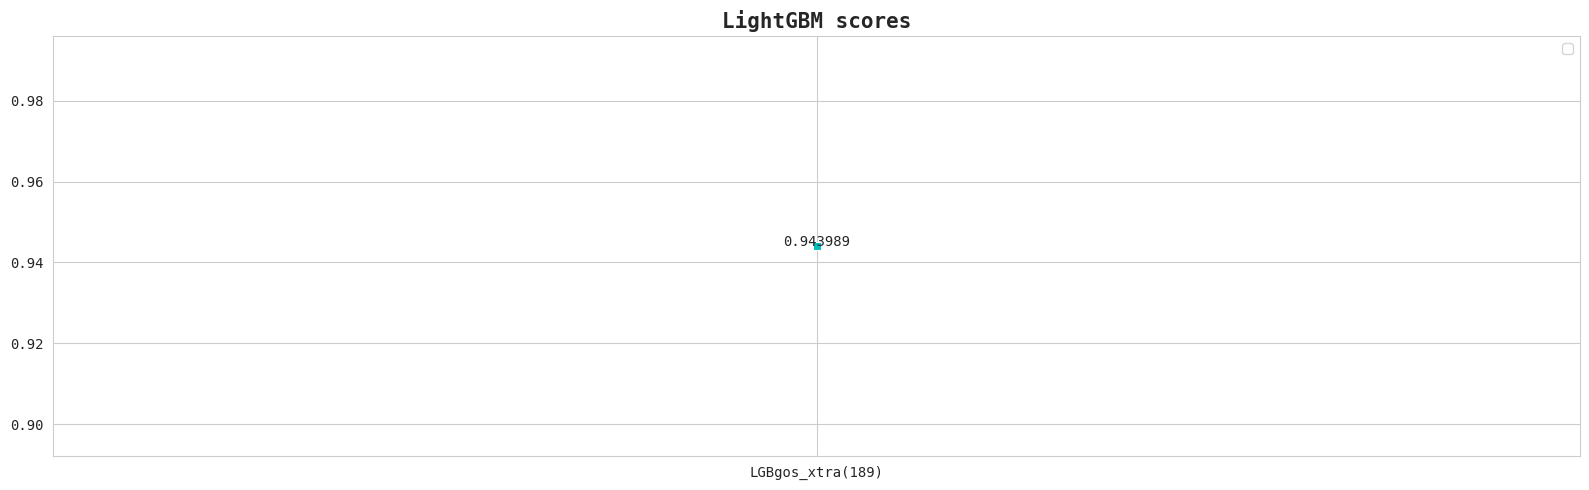

In [40]:
all_scores = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for x, y in v.items():
        if x == "score":
            all_scores[k] = y

plt.figure(figsize=(16, 5))
ax1 = sns.lineplot([*all_scores.values()], marker="s")

y_add = 1e-6

for i, s1 in enumerate([*all_scores.values()]):
    ax1.text(float(i), s1+y_add, s1, ha="center", va="baseline")

# plt.ylim((0.94, 0.955))
plt.legend(loc="best")
plt.xticks(range(len(all_scores)), [*all_scores.keys()], rotation=0)
plt.title("LightGBM scores", fontdict={"weight": "semibold", "size": 15})

plt.tight_layout() 
plt.show()

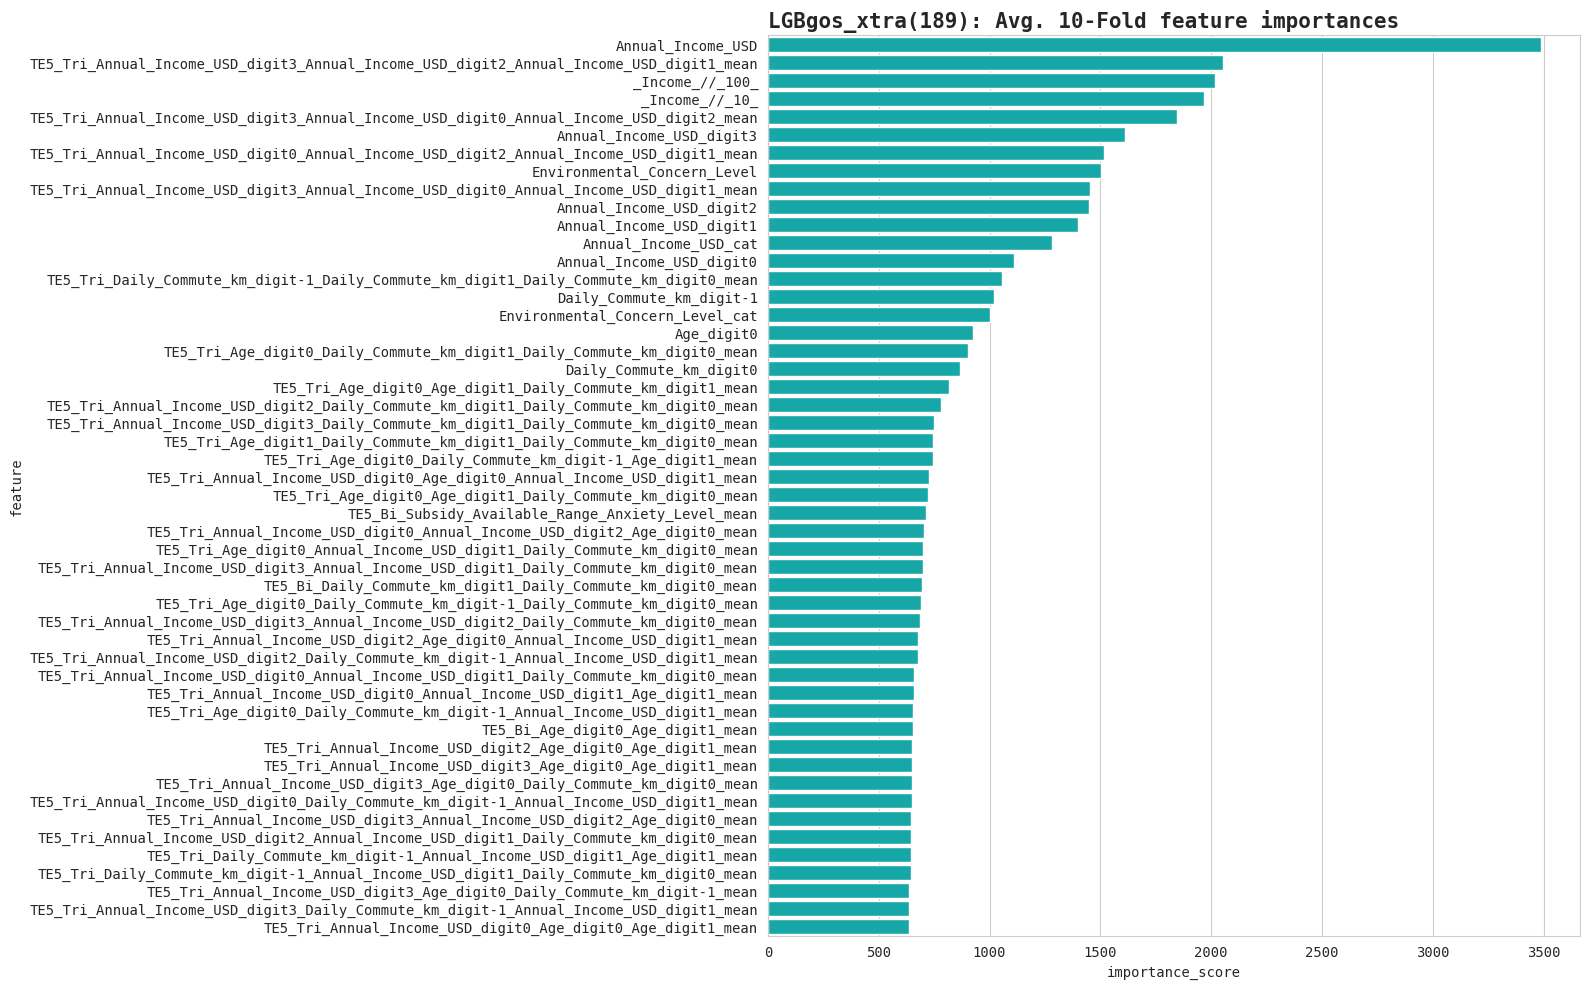

In [41]:
all_importances = {}
all_val_data = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for x, y in v.items():
        if x == "importances":
            all_importances[k] = np.mean(y, axis=0)
        elif x == "val_data":
            all_val_data[k] = y # -> [0] select X_val, [1] select y_valid

top_n = 50

for i, (m, fi) in enumerate(all_importances.items()):
    fi_df = pd.DataFrame({
        "feature": all_val_data[m][0].columns,
        "importance_score": fi,
    }).sort_values(by="importance_score", ascending=False).reset_index(drop=True)
    
    plt.figure(figsize=(16, len(all_importances)*10))
    plt.subplot(len(all_importances), 1, i+1)
    sns.barplot(data=fi_df.head(top_n), x="importance_score", y="feature")
    plt.title(f"{m}: Avg. {FOLDS}-Fold feature importances", size=15, weight="semibold", loc='left')

    plt.tight_layout() 
    plt.show()

    print()

LGBgos_xtra(189)_943989 saved!


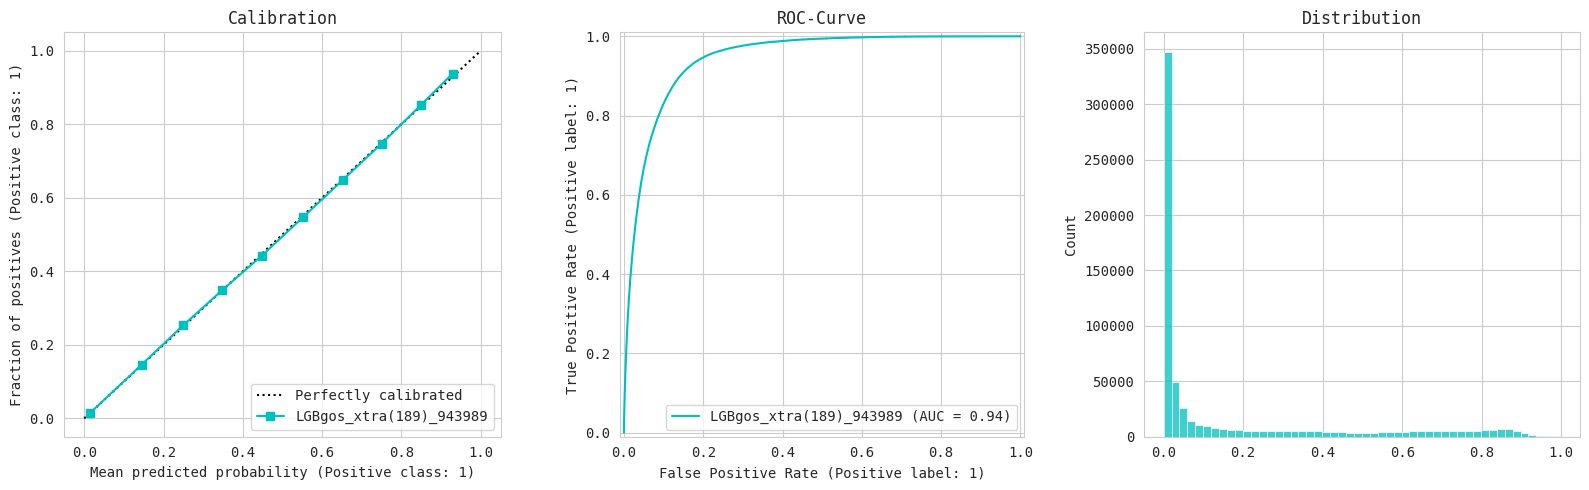

In [42]:
## -- Get oof predictions --

for i, (k, v) in enumerate(all_predictions.items()):
    for key_, data_ in v.items():
        if key_ == "oof_preds":
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"oof_{n}.npy", data_)
            print(f"{n} saved!")

            ## -- Plot distributions --
            _, axs = plt.subplots(1, 3, figsize=(16, 5)) 
            CalibrationDisplay.from_predictions(train_X[TARGET], data_, n_bins=10, name=n, ax=axs[0])
            axs[0].set_title("Calibration")

            RocCurveDisplay.from_predictions(train_X[TARGET], data_, name=n, ax=axs[1])
            axs[1].set_title("ROC-Curve")

            sns.histplot(data_, ax=axs[2], bins=50)
            axs[2].set_title("Distribution")
            
            plt.tight_layout()
            plt.show()

            print()

In [43]:
## -- Save test predictions/submissions --
model_results = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == "test_preds":
            ## -- Base submission file --
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"test_{n}.npy", y)

            submission[TARGET] = y
            submission.to_csv(f"submit_{n}.csv", index=False)
            print(f"{n} saved! {y.shape}")

            model_results[n[:-6]] = y

print()
model_results = pd.DataFrame(model_results)
model_results

LGBgos_xtra(189)_943989 saved! (286571,)



,LGBgos_xtra(189)_
0,0.010071
1,0.010850
2,0.020665
3,0.004774
4,0.011343
...,...
286566,0.000582
286567,0.074336
286568,0.001822
286569,0.001037


In [44]:
# !rm -r /kaggle/working